In [1]:
from collections import defaultdict
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Subset

from spectre.datasets import RFUAVDataset

%load_ext autoreload
%autoreload 2

In [2]:
# Apply roughly the same transformations as the RFUAV repo

#La idea es que el modelo no vea siempre la misma imagen exactamente igual, sino versiones ligeramente alteradas.
#

train_transform = A.Compose(   #Compose quiere decir: aplica estas transformaciones en este orden
    [
        A.Resize(224, 224), #Fuerza a que todas las imágenes tengan tamaño 224 × 224.
        A.OneOf( #Aplica una de las siguientes transformaciones con una probabilidad de 0.5
            [
                A.AdvancedBlur( #Aplica un desenfoque avanzado, simula una imagen menos nitida, como si estuviera fuera de foco o en movimiento.
                    blur_limit=(7, 13),
                    sigma_x_limit=(7, 13),
                    sigma_y_limit=(7, 13),
                    rotate_limit=(-90, 90),
                    beta_limit=(0.5, 8),
                    noise_limit=(2, 10),
                    p=1,
                ),
                A.CLAHE( #Aplica el algoritmo CLAHE (Contrast Limited Adaptive Histogram Equalization) Resalta zonas que antes podían verse demasiado apagadas o poco diferenciadas
                    clip_limit=3,
                    tile_grid_size=(13, 13),
                    p=1,
                ),
                A.ColorJitter( #Aquí realmente solo cambia el brillo
                    brightness=(0.5, 1.5),
                    contrast=(1, 1),
                    saturation=(1, 1),
                    hue=(-0, 0),
                    p=1,
                ),
                A.GaussNoise(p=1), #Añade ruido gaussiano a la imagen.
                A.ISONoise(
                    intensity=(0.2, 0.5),
                    color_shift=(0.01, 0.05),
                    p=1,
                ),
                A.Sharpen(#Hace la imagen más nítida.
                    alpha=(0.2, 0.5),
                    lightness=(0.5, 1),
                    p=1,
                ),
            ],
            p=0.5,
        ),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(), #Convierte la imagen final en un tensor de PyTorch. Es el último paso antes de que la imagen pueda entrar en la red.
    ]
)

# For validation and testing, we only want to resize and normalize the images

#En entrenamiento quieres que el modelo aprenda a generalizar.
#En validación quieres medirlo de forma limpia.
#Porque en validación quieres medir el rendimiento del modelo de forma estable y justa.

#Si metieras transformaciones aleatorias en validación:

#cada evaluación sería distinta
#no sabrías si el cambio en accuracy viene del modelo o de la transformación aleatoria

val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(), 
    ]
)

test_transform = val_transform

data_path = Path("/datasets")
train_set = RFUAVDataset(
    data_path / "ImageSet-AllDrones-MatlabPipeline/train", transform=train_transform
)
val_set = RFUAVDataset(
    data_path / "ImageSet-AllDrones-MatlabPipeline/valid", transform=val_transform
)
test_set = RFUAVDataset(
    data_path / "ValidationSet_5Drones", transform=test_transform)

In [3]:
params = {
    "epochs": 25,
    "learning_rate": 1e-4,
    "batch_size": 32,
    "test_batch_size": 16,
}

The train and validation datasets contain spectrograms for many different classes or targets, but we will focus only on DJI drones, just like in the original paper. On the other hand, the test dataset already contains only these targets. We filter using the targets and create a mapping for the old class indices to the new ones (i.e., start from zero).

In [4]:
def filter_dataset_by_classes(dataset, selected_classes):
    indices = [
        i for i, target in enumerate(dataset.targets) if target in selected_classes
    ]
    return Subset(dataset, indices)


selected_classes = [
    "DJI AVATA2",
    "DJI FPV COMBO",
    "DJI MAVIC3 PRO",
    "DJI MINI3",
    "DJI MINI4 PRO",
]

selected_classes_indices = [train_set.class_to_idx[c]
                            for c in selected_classes]

train_subset = filter_dataset_by_classes(train_set, selected_classes_indices)
val_subset = filter_dataset_by_classes(val_set, selected_classes_indices)

class_to_idx_mapping = {
    old_idx: new_idx for new_idx, old_idx in enumerate(selected_classes_indices)
}


def remap_target_labels(target):
    return class_to_idx_mapping[target]


train_subset.dataset.target_transform = remap_target_labels
val_subset.dataset.target_transform = remap_target_labels

For testing, we only take the spectrograms with the Parula colormap and 256 STFT points. A loader is created for each SNR value in order to measure performance per value.

In [6]:
snr_to_indices = defaultdict(list)
for idx, snr in enumerate(test_set.snr):
    if snr is not None:
        if (
            test_set.cmap[idx] == "parula" and test_set.stftp[idx] == 256
        ):  # Ensure we only include parula samples with stftp=1
            snr_to_indices[snr].append(idx)

snr_subsets = {
    snr: Subset(test_set, indices) for snr, indices in snr_to_indices.items()
}

snr_loaders = {
    snr: DataLoader(subset, batch_size=params["test_batch_size"],
                    num_workers=3, shuffle=False)
    for snr, subset in sorted(snr_subsets.items())
}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


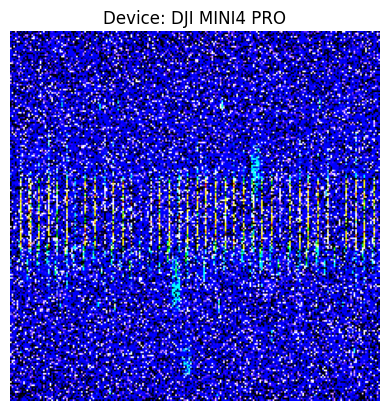

In [7]:
example = train_subset[np.random.randint(len(train_subset))]
image = example[0]
label = example[1]

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Device: {selected_classes[label]}")
plt.axis("off")
plt.show()

In [8]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("RFUAV Classification")

with mlflow.start_run():
    mlflow.log_params(params)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on device: {device}")

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(selected_classes))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        train_subset, batch_size=params["batch_size"], shuffle=True
    )
    val_loader = DataLoader(
        val_subset, batch_size=params["batch_size"], shuffle=False
    )

    # NUEVO: para guardar el mejor modelo
    best_val_acc = 0.0
    best_state = None

    # OPCIONAL: early stopping
    patience = 6
    epochs_without_improvement = 0

    for epoch in range(params["epochs"]):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100.0 * correct / total

        # Validation step
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100.0 * correct / total

        mlflow.log_metrics(
            {
                "train_loss": avg_train_loss,
                "train_acc": train_acc,
                "val_loss": avg_val_loss,
                "val_acc": val_acc,
            },
            step=epoch,
        )

        print(
            f"Epoch {epoch+1}/{params['epochs']} - "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%"
        )

        # NUEVO: guardar mejor modelo
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # OPCIONAL: early stopping
        if epochs_without_improvement >= patience:
            print(f"Early stopping en epoch {epoch+1}")
            break

    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    # NUEVO: cargar mejor modelo antes del test SNR
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    # OPCIONAL: guardar modelo
    torch.save(model.state_dict(), "rfuav_resnet18_best.pth")
    mlflow.log_artifact("rfuav_resnet18_best.pth")

    # Free training-only GPU allocations before test-time SNR evaluation.
    del train_loader, val_loader, optimizer, criterion
    for p in model.parameters():
        p.grad = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model.eval()
    snr_accuracies = {}
    with torch.inference_mode():
        for snr, loader in snr_loaders.items():
            correct = 0
            total = 0
            for inputs, targets in loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

            test_acc = 100.0 * correct / total
            snr_accuracies[snr] = test_acc
            mlflow.log_metric(f"snr_{snr}_acc", test_acc)
            print(f"SNR: {snr} dB - Accuracy: {test_acc:.4f}")

Running on device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/vscode/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 23.9MB/s]


Epoch 1/25 - Train Loss: 0.3009, Train Acc: 89.77%, Val Loss: 0.0130, Val Acc: 99.78%
Epoch 2/25 - Train Loss: 0.0424, Train Acc: 99.12%, Val Loss: 0.0053, Val Acc: 99.89%
Epoch 3/25 - Train Loss: 0.0382, Train Acc: 99.12%, Val Loss: 0.0034, Val Acc: 99.93%
Epoch 4/25 - Train Loss: 0.0148, Train Acc: 99.64%, Val Loss: 0.0028, Val Acc: 99.91%
Epoch 5/25 - Train Loss: 0.0127, Train Acc: 99.74%, Val Loss: 0.0027, Val Acc: 99.89%
Epoch 6/25 - Train Loss: 0.0099, Train Acc: 99.84%, Val Loss: 0.0020, Val Acc: 99.98%
Epoch 7/25 - Train Loss: 0.0068, Train Acc: 99.79%, Val Loss: 0.0032, Val Acc: 99.91%
🏃 View run aged-shark-512 at: http://mlflow:5000/#/experiments/1/runs/9e3b6466c44046c0bc72e112633db139
🧪 View experiment at: http://mlflow:5000/#/experiments/1


KeyboardInterrupt: 

In [9]:
torch.save(model.state_dict(), "rfuav_resnet18_epoch6.pth")
print("Modelo guardado")

Modelo guardado


In [10]:
model.eval()
snr_accuracies = {}

with torch.inference_mode():
    for snr, loader in snr_loaders.items():
        correct = 0
        total = 0

        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        test_acc = 100.0 * correct / total
        snr_accuracies[snr] = test_acc
        print(f"SNR: {snr} dB - Accuracy: {test_acc:.4f}")

SNR: -20 dB - Accuracy: 10.3343
SNR: -18 dB - Accuracy: 10.6383
SNR: -16 dB - Accuracy: 12.4620
SNR: -14 dB - Accuracy: 11.5502
SNR: -12 dB - Accuracy: 11.8541
SNR: -10 dB - Accuracy: 10.1824
SNR: -8 dB - Accuracy: 9.5745
SNR: -6 dB - Accuracy: 8.8146
SNR: -4 dB - Accuracy: 8.6626
SNR: -2 dB - Accuracy: 8.6626
SNR: 0 dB - Accuracy: 8.5106
SNR: 2 dB - Accuracy: 8.3587
SNR: 4 dB - Accuracy: 15.6535
SNR: 6 dB - Accuracy: 32.5228
SNR: 8 dB - Accuracy: 38.2979
SNR: 10 dB - Accuracy: 42.8571
SNR: 12 dB - Accuracy: 45.7447
SNR: 14 dB - Accuracy: 48.3283
SNR: 16 dB - Accuracy: 56.5350
SNR: 18 dB - Accuracy: 65.3495
SNR: 20 dB - Accuracy: 72.6444


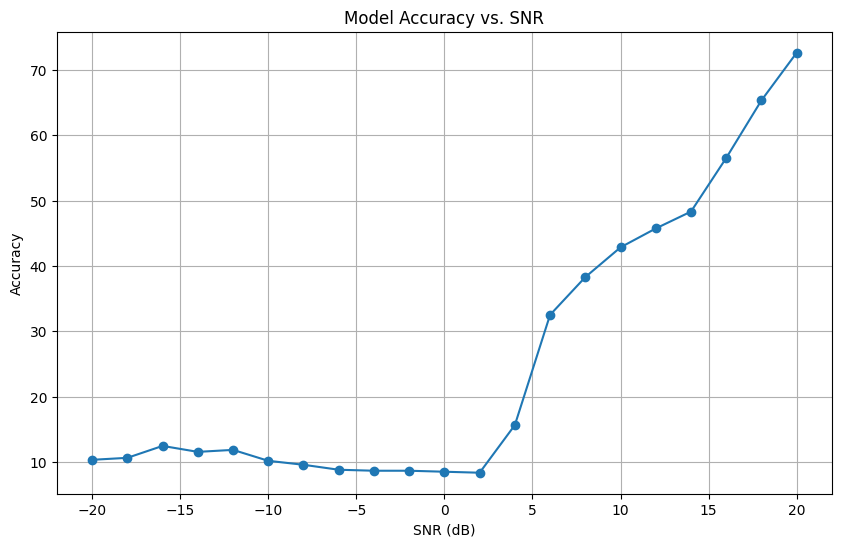

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(list(snr_accuracies.keys()), list(
    snr_accuracies.values()), marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs. SNR")
plt.grid(True)
plt.show()